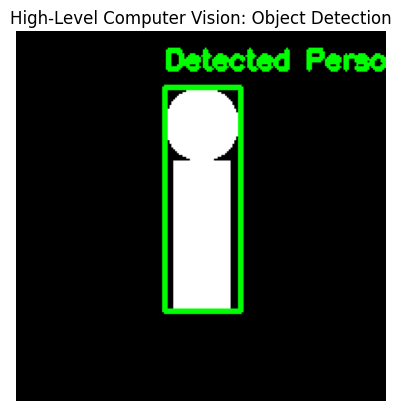

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Create a blank image
img = np.zeros((200, 200, 3), dtype=np.uint8)

# Step 2: Draw a synthetic "person" (head + body)
cv2.circle(img, (100, 50), 20, (255, 255, 255), -1)      # Head
cv2.rectangle(img, (85, 70), (115, 150), (255, 255, 255), -1)  # Body

# Step 3: Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 4: Threshold to identify the object
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# Step 5: Find contours
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL,
                               cv2.CHAIN_APPROX_SIMPLE)

# Step 6: Detect and classify the object
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)

    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(img, "Detected Person", (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Step 7: Display result
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("High-Level Computer Vision: Object Detection")
plt.axis("off")
plt.show()